In [67]:
import pandas as pd
import numpy as np

In [68]:
filename = "/home/lacrio/cryoextremes-practicals/data/buoy/data_bouy.csv"

df_bouy = pd.read_csv(filename, sep='\t')
df_bouy['datetime'] = pd.to_datetime(df_bouy['datetime'])

df_bouy['datetime'] = df_bouy['datetime'] + pd.Timedelta(hours=3)

df_bouy = df_bouy.set_index('datetime')

df_bouy

,ws,tair,rh,press,SUp,sst
datetime,,,,,,
2024-12-05 03:00:00,5.020934,-0.4,80.0,1009.0,0.00,-0.180133
2024-12-05 04:00:00,4.568227,-0.6,81.0,1009.2,0.00,-0.193667
2024-12-05 05:00:00,5.211277,-0.4,77.0,1009.5,0.00,-0.173117
2024-12-05 06:00:00,4.748281,-0.4,75.4,1009.6,0.00,-0.129300
2024-12-05 07:00:00,2.608211,-0.5,79.7,1009.8,0.00,-0.119543
...,...,...,...,...,...,...
2024-12-13 22:00:00,5.977793,2.0,83.2,993.5,317.90,0.711133
2024-12-13 23:00:00,5.519941,1.9,84.5,994.0,220.00,0.726267
2024-12-14 00:00:00,6.610554,2.2,79.4,994.2,78.56,0.729700


In [69]:
from coare35vn import coare35vn

In [74]:
# =====================================================
# COARE 3.5
# =====================================================
A = coare35vn(
    df_bouy['ws'].values, df_bouy['tair'].values,  df_bouy['rh'].values, df_bouy['sst'].values,
    P=df_bouy['press'].values, Rs=df_bouy['SUp'].values, Rl=288,
    zu=1.8, zt=1.8, zq=1.8,
    lat=-62.109, zi=300,
    rain=np.zeros_like(df_bouy['ws']),
    jcool=1
)

/home/lacrio/cryoextremes-practicals/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


In [75]:
#df_bouy['H'] =  A[:, 2]
#df_bouy['LE'] = A[:, 3]

# Filtra directamente la matriz A antes o durante la asignación
df_bouy['H'] = np.where(np.abs(A[:, 2]) > 150, np.nan, A[:, 2])
df_bouy['LE'] = np.where(np.abs(A[:, 3]) > 150, np.nan, A[:, 3])


In [76]:
df_bouy

,ws,tair,rh,press,SUp,sst,H,LE
datetime,,,,,,,,
2024-12-05 03:00:00,5.020934,-0.4,80.0,1009.0,0.00,-0.180133,1.306322,17.196532
2024-12-05 04:00:00,4.568227,-0.6,81.0,1009.2,0.00,-0.193667,2.827056,15.917835
2024-12-05 05:00:00,5.211277,-0.4,77.0,1009.5,0.00,-0.173117,1.402831,20.641650
2024-12-05 06:00:00,4.748281,-0.4,75.4,1009.6,0.00,-0.129300,1.618922,20.593856
2024-12-05 07:00:00,2.608211,-0.5,79.7,1009.8,0.00,-0.119543,1.326139,9.692984
...,...,...,...,...,...,...,...,...
2024-12-13 22:00:00,5.977793,2.0,83.2,993.5,317.90,0.711133,-14.500201,7.269809
2024-12-13 23:00:00,5.519941,1.9,84.5,994.0,220.00,0.726267,-12.274426,5.992939
2024-12-14 00:00:00,6.610554,2.2,79.4,994.2,78.56,0.729700,-18.344183,11.766207


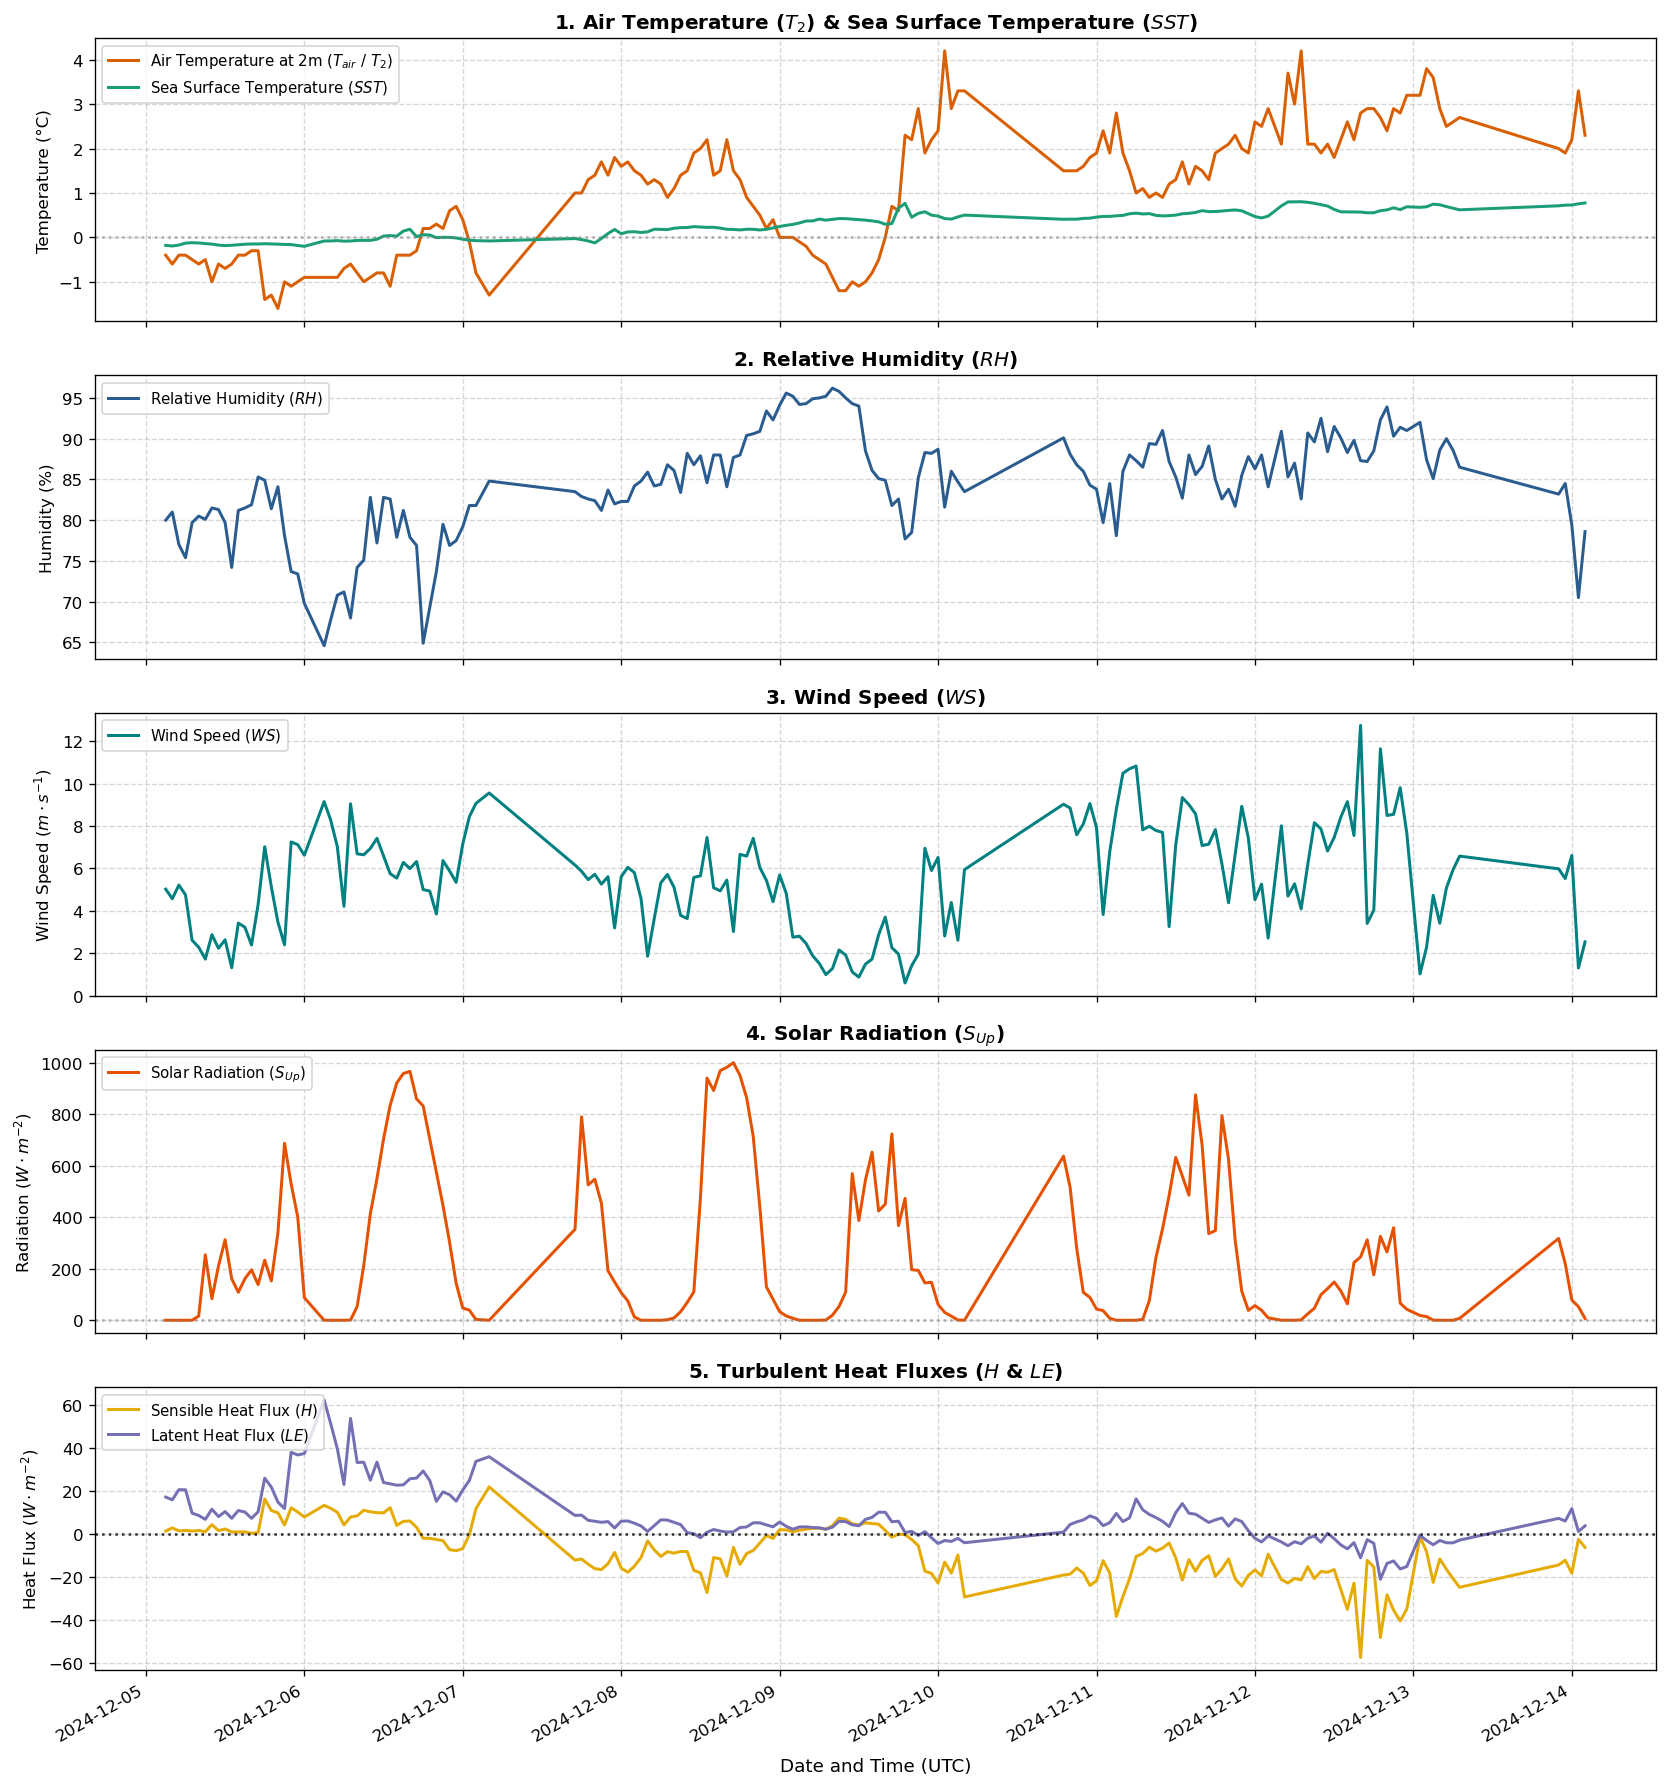

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copiar el DataFrame manteniendo todos los NaN
df_plot = df_bouy.copy()

# 2. Configurar la figura con 5 subplots
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(14, 15), sharex=True, dpi=120
)

# --- SUBPLOT 1: Temperaturas (tair / T2 y sst) ---
ax1.plot(
    df_plot.index,
    df_plot['tair'],
    label='Air Temperature at 2m ($T_{air}$ / $T_2$)',
    color='#d95f02',
    linewidth=1.8,
)
ax1.plot(
    df_plot.index,
    df_plot['sst'],
    label='Sea Surface Temperature ($SST$)',
    color='#1b9e77',
    linewidth=1.8,
)

ax1.set_title(
    '1. Air Temperature ($T_2$) & Sea Surface Temperature ($SST$)',
    fontsize=12,
    fontweight='bold',
)
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 2: Humedad Relativa (rh) ---
ax2.plot(
    df_plot.index,
    df_plot['rh'],
    label='Relative Humidity ($RH$)',
    color='#2b5c8f',
    linewidth=1.8,
)

ax2.set_title('2. Relative Humidity ($RH$)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Humidity (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 3: Velocidad del Viento (ws) ---
ax3.plot(
    df_plot.index,
    df_plot['ws'],
    label='Wind Speed ($WS$)',
    color='#008080',
    linewidth=1.8,
)

ax3.set_title('3. Wind Speed ($WS$)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Wind Speed ($m \\cdot s^{-1}$)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 4: Radiación Solar Incidente/Reflejada (SUp) ---
ax4.plot(
    df_plot.index,
    df_plot['SUp'],
    label='Solar Radiation ($S_{Up}$)',
    color='#e65100',
    linewidth=1.8,
)

ax4.set_title('4. Solar Radiation ($S_{Up}$)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Radiation ($W \\cdot m^{-2}$)', fontsize=10)
ax4.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 5: Flujos Turbulentos de Calor (H & LE) ---
ax5.plot(
    df_plot.index,
    df_plot['H'],
    label='Sensible Heat Flux ($H$)',
    color='#e6ab02',
    linewidth=1.8,
)
ax5.plot(
    df_plot.index,
    df_plot['LE'],
    label='Latent Heat Flux ($LE$)',
    color='#7570b3',
    linewidth=1.8,
)

ax5.set_title(
    '5. Turbulent Heat Fluxes ($H$ & $LE$)',
    fontsize=12,
    fontweight='bold',
)
ax5.set_xlabel('Date and Time (UTC)', fontsize=11, labelpad=8)
ax5.set_ylabel('Heat Flux ($W \\cdot m^{-2}$)', fontsize=10)
ax5.axhline(0, color='black', linestyle=':', alpha=0.8)
ax5.grid(True, linestyle='--', alpha=0.5)
ax5.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# Formato final
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()